<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/Projeto_Hidr%C3%A1ulico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Altura da lâmina d'água: 0.720 m


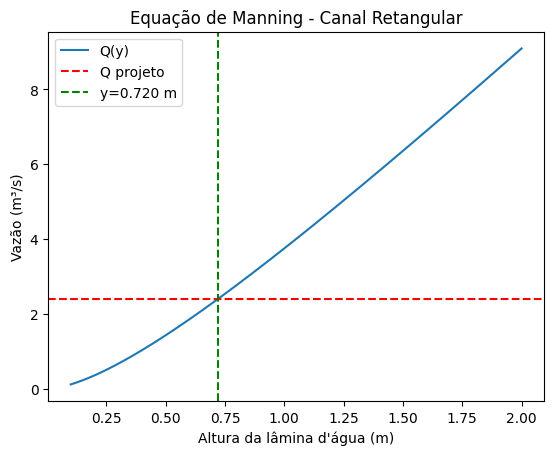

Fator de atrito Darcy: 0.0400
Perda de carga contínua: 1.631 m


In [4]:
"""
PROJETO HIDRÁULICO

Objetivo:
Este programa realiza dois cálculos hidráulicos fundamentais:
1. Dimensionamento de canal retangular pelo método de Manning.
2. Cálculo da perda de carga em conduto forçado pelo método de Darcy-Weisbach.


Saídas:
- Altura da lâmina d’água (y) necessária para transportar a vazão de projeto.
- Gráfico da relação entre vazão e altura do canal.
- Fator de atrito de Darcy para regime laminar.
- Perda de carga contínua ao longo da tubulação.

Referências:
- Equação de Manning para escoamento uniforme em canais.
- Equação de Darcy-Weisbach para perda de carga em condutos forçados.

Autor: Fábio Lima Guimarães

"""

import math
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Situação 1: Canal Retangular
# -------------------------------
def manning_canal(Q, n, I, b):
    """
    Calcula a altura da lâmina d'água (y) para um canal retangular
    usando a equação de Manning.
    """
    def vazao(y):
        A = b * y
        P = b + 2*y
        R = A / P
        return (1/n) * A * (R**(2/3)) * (I**0.5)

    # Iteração numérica para encontrar y
    y = 0.1
    while vazao(y) < Q:
        y += 0.001
    return y

# Dados
n = 0.013
Q = 2.40
I = 0.0015
b = 2.00

y = manning_canal(Q, n, I, b)
print(f"Altura da lâmina d'água: {y:.3f} m")

# Gráfico da relação vazão x altura
ys = np.linspace(0.1, 2.0, 200)
Qs = [(1/n) * (b*y) * ((b*y)/(b+2*y))**(2/3) * (I**0.5) for y in ys]

plt.plot(ys, Qs, label="Q(y)")
plt.axhline(Q, color='r', linestyle='--', label="Q projeto")
plt.axvline(y, color='g', linestyle='--', label=f"y={y:.3f} m")
plt.xlabel("Altura da lâmina d'água (m)")
plt.ylabel("Vazão (m³/s)")
plt.legend()
plt.title("Equação de Manning - Canal Retangular")
plt.show()

# -------------------------------
# Situação 2: Conduto Forçado
# -------------------------------
def perda_carga(D, L, v, Re, g):
    # Fator de atrito Darcy para regime laminar
    f = 64 / Re
    hf = f * (L/D) * (v**2 / (2*g))
    return f, hf

D = 0.10
L = 500
v = 0.40
Re = 1600
g = 9.81

f, hf = perda_carga(D, L, v, Re, g)
print(f"Fator de atrito Darcy: {f:.4f}")
print(f"Perda de carga contínua: {hf:.3f} m")